In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Math
import sympy as sp

eps = 1e-3
n = 6

x_sym = sp.Symbol('x')
x = np.array([0, 0.2, 0.4, 0.6, 0.8, 1])
y = np.array([1, 1.0032, 1.0512, 1.2592, 1.8192, 3])

# Метод наименьших квадратов

Определим функцию, которая строит матрицу коэффициентов системы для метода наименьших квадратов для многочлена степени $order$:

In [44]:
def build_mnk_system(order):
    s = np.array([np.sum(x ** p) for p in range(2 * order + 1)], dtype=float)

    A = np.fromfunction(
        lambda k, i: s[(k + i).astype(int)],
        (order + 1, order + 1)
    )

    b = np.array([np.sum(y * (x ** k)) for k in range(order + 1)], dtype=float)

    return A, b

# Многочлен 1-ой степени

Составим систему для многочлена 1-ой степени:

In [45]:
order = 1

A, b = build_mnk_system(order)
display(pd.DataFrame(A), pd.DataFrame(b))

,0,1
0,6.0,3.0
1,3.0,2.2


,0
0,9.1328
1,5.8320


Решим СЛАУ

In [46]:
mnk_coefficients = np.linalg.solve(A, b)
display(pd.DataFrame(mnk_coefficients, columns=["a_i"]))

,a_i
0,0.618133
1,1.808000


Получившийся полиномиальный многочлен первой степени:

In [47]:
polynomial_first = sum(mnk_coefficients[i] * x_sym ** i for i in range(order + 1))

display(Math(rf"F_{{{order}}}(x) = {sp.latex(sp.expand(polynomial_first))}"))

<IPython.core.display.Math object>

Посчитаем сумму квадратов ошибок для многочлена первой степени:

In [48]:
sum(
    (float(polynomial_first.subs(x_sym, x[i]).evalf()) - y[i]) *
    (float(polynomial_first.subs(x_sym, x[i]).evalf()) - y[i])
    for i in range(len(x))
)

np.float64(0.8169608533333335)

# Многочлен 2-ой степени

Составим систему для многочлена 2-ой степени:

In [49]:
order = 2

A, b = build_mnk_system(order)
display(pd.DataFrame(A), pd.DataFrame(b))

,0,1,2
0,6.0,3.0,2.2000
1,3.0,2.2,1.8000
2,2.2,1.8,1.5664


,0
0,9.13280
1,5.83200
2,4.82592


Решим СЛАУ

In [50]:
mnk_coefficients = np.linalg.solve(A, b)
display(pd.DataFrame(mnk_coefficients, columns=["a_i"]))

,a_i
0,1.090514
1,-1.734857
2,3.542857


Получившийся полиномиальный многочлен второй степени:

In [51]:
polynomial_second = sum(mnk_coefficients[i] * x_sym ** i for i in range(order + 1))

display(Math(rf"F_{{{order}}}(x) = {sp.latex(sp.expand(polynomial_second))}"))

<IPython.core.display.Math object>

Посчитаем сумму квадратов ошибок для многочлена второй степени:

In [52]:
sum(
    (float(polynomial_second.subs(x_sym, x[i]).evalf()) - y[i]) *
    (float(polynomial_second.subs(x_sym, x[i]).evalf()) - y[i])
    for i in range(len(x))
)

np.float64(0.06719780571428592)

# Визуализация

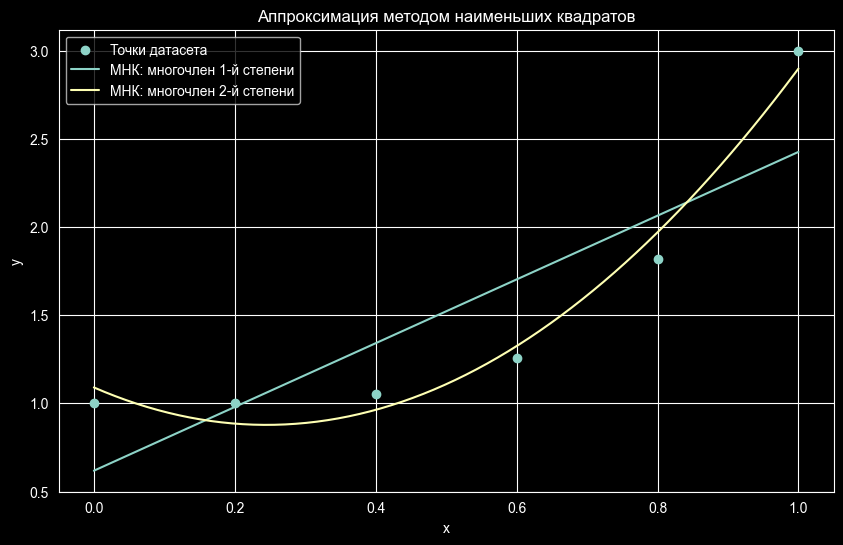

In [55]:
x_plot = np.linspace(x.min(), x.max(), 200)

polynomial_first_func = sp.lambdify(x_sym, polynomial_first, modules="numpy")
polynomial_second_func = sp.lambdify(x_sym, polynomial_second, modules="numpy")

plt.figure(figsize=(10, 6))

plt.scatter(x, y, label="Точки датасета", zorder=3)
plt.plot(x_plot, polynomial_first_func(x_plot), label="МНК: многочлен 1-й степени")
plt.plot(x_plot, polynomial_second_func(x_plot), label="МНК: многочлен 2-й степени")

plt.title("Аппроксимация методом наименьших квадратов")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

# Валидация

Используем готовые средства numpy для проверки получившихся многочленов.</br> Сравним их с результатами, полученными вручную.

In [54]:
order = 1
mnk_numpy_coeffs_first = np.polynomial.polynomial.polyfit(x, y, order)
polynomial_numpy_first = sum(mnk_numpy_coeffs_first[i] * x_sym ** i for i in range(order + 1))

display(Math(rf"F_{{{order}}}(x) = {sp.latex(sp.expand(polynomial_first))}"))
display(Math(rf"F_{{{order}}}(x) = {sp.latex(sp.expand(polynomial_numpy_first))}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [53]:
order = 2
mnk_numpy_coeffs_second = np.polynomial.polynomial.polyfit(x, y, order)
polynomial_numpy_second = sum(mnk_numpy_coeffs_second[i] * x_sym ** i for i in range(order + 1))

display(Math(rf"F_{{{order}}}(x) = {sp.latex(sp.expand(polynomial_second))}"))
display(Math(rf"F_{{{order}}}(x) = {sp.latex(sp.expand(polynomial_numpy_second))}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>